# Optimal Transport on 3D Mesh Graphs

This notebook demonstrates the Flow Sinkhorn algorithm applied to the graph defined by the edges of a 3D triangular mesh.

We will:
1. Load a 3D mesh from an OFF file
2. Visualize the mesh and its vertices
3. Select source vertices (top) and sink vertices (bottom)
4. Compute exact optimal transport using linear programming
5. Compute approximate transport using Flow Sinkhorn with different regularization levels
6. Visualize the flow on the mesh edges

In [3]:
# Install Flow Sinkhorn from GitHub (for Colab)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running on Colab - installing flowsinkhorn from GitHub...')
    !pip install -q git+https://github.com/gpeyre/flow-sinkhorn.git
    !pip install -q sparse
    !wget -q https://raw.githubusercontent.com/gpeyre/flow-sinkhorn/main/data/moomoo.off
    mesh_path = 'moomoo.off'
    print('Installation complete!')

else:
    print('Running locally - using local flowsinkhorn')
    import sys
    from pathlib import Path

    cwd = Path.cwd().resolve()
    repo_root = cwd.parent if cwd.name == 'examples' else cwd
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    mesh_path = str(repo_root / 'data' / 'moomoo.off')

Running locally - using local flowsinkhorn


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import time
import warnings

# Import Flow Sinkhorn toolbox
from flowsinkhorn import sinkhorn_w1_sparse, solve_w1_exact
from flowsinkhorn.toolbox import (
    load_off_file,
    build_mesh_graph,
    plot_mesh,
    plot_mesh_with_flow_interactive,
    plot_mesh_with_flow,
    select_sources_sinks,
)

# Robust interactive import for notebooks with stale module cache
try:
    from flowsinkhorn.toolbox import plot_mesh_interactive
except ImportError:
    from flowsinkhorn.toolbox.mesh import plot_mesh_interactive

import sparse

warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Load 3D Mesh from OFF File

The OFF (Object File Format) is a simple format for storing 3D geometry:
- First line: "OFF"
- Second line: number of vertices, number of faces, number of edges
- Next lines: vertex coordinates (x, y, z)
- Remaining lines: face vertex indices

In [5]:
# Load mesh from OFF file
vertices, faces = load_off_file(mesh_path)

print(f"Mesh loaded:")
print(f"  - {len(vertices)} vertices")
print(f"  - {len(faces)} faces")
print(f"  - Bounding box: [{vertices.min(axis=0)}, {vertices.max(axis=0)}]")

Mesh loaded:
  - 1045 vertices
  - 2086 faces
  - Bounding box: [[-18.96347457 -20.19701293 -11.08628754], [17.20497048 29.20879885 17.09787694]]


## 2. Build Graph from Mesh Edges

We construct an undirected graph where:
- Nodes are mesh vertices
- Edges connect vertices that share a face
- Edge weights are Euclidean distances

In [6]:
# Build graph from mesh edges
A, W, _ = build_mesh_graph(vertices, faces)

print(f"Graph built:")
print(f"  - {len(vertices)} vertices")
print(f"  - {np.sum(A) // 2} edges (undirected)")
print(f"  - Average degree: {A.sum() / len(vertices):.2f}")
print(f"  - Min edge weight: {W[A > 0].min():.6f}")
print(f"  - Max edge weight: {W[A > 0].max():.6f}")

Graph built:
  - 1045 vertices
  - 3129 edges (undirected)
  - Average degree: 5.99
  - Min edge weight: 1.502913
  - Max edge weight: 2.716580


## 3. Visualize the 3D Mesh

Display the mesh with vertices highlighted.

In [7]:
# Visualize the mesh (interactive)
fig = plot_mesh_interactive(
    vertices,
    faces,
    title="Interactive 3D Mesh",
    show_edges=True,
    edge_color="black",
    edge_width=0.45,
    mesh_opacity=1.0,
)
fig.show()

## 4. Select Source and Sink Vertices

We select:
- **Sources** (red): k vertices with highest z-coordinate (top of mesh)
- **Sinks** (blue): k vertices with lowest z-coordinate (bottom of mesh)

In [8]:
# Select k=3 sources (top) and k=3 sinks (bottom)
k = 3
sources, sinks, z = select_sources_sinks(vertices, k=k, axis=2)

print(f"Selected vertices:")
print(f"  - {len(sources)} sources (top, z-max)")
print(f"  - {len(sinks)} sinks (bottom, z-min)")
print(f"  - Mass conservation: sum(z) = {z.sum():.2e}")

# Visualize sources and sinks (interactive)
fig = plot_mesh_interactive(
    vertices,
    faces,
    z=z,
    title="Interactive Mesh with Sources (red) and Sinks (blue)",
    show_edges=True,
    edge_color="black",
    edge_width=0.45,
    mesh_opacity=1.0,
)
fig.show()

Selected vertices:
  - 3 sources (top, z-max)
  - 3 sinks (bottom, z-min)
  - Mass conservation: sum(z) = 0.00e+00


## 5. Exact Optimal Transport (Linear Programming)

Compute the exact optimal transport using CVXPY.

This solves:
$$
\min_{F \geq 0} \langle F, W \rangle \quad \text{s.t.} \quad F^\top \mathbf{1} - F \mathbf{1} = z
$$

In [9]:
print("Computing exact optimal transport...")
start = time.time()
F_exact, obj_exact, status = solve_w1_exact(W, z, verbose=False)
time_exact = time.time() - start

print(f"Exact solver:")
print(f"  - Status: {status}")
print(f"  - Optimal cost: {obj_exact:.6f}")
print(f"  - Time: {time_exact:.2f}s")
print(f"  - Non-zero flows: {np.sum(F_exact > 1e-6)}")

Computing exact optimal transport...
Exact solver:
  - Status: optimal
  - Optimal cost: 170.457566
  - Time: 17.98s
  - Non-zero flows: 1206


In [13]:
# Visualize exact flow (interactive)
threshold_exact = F_exact.max() / 50
fig = plot_mesh_with_flow_interactive(
    vertices,
    faces,
    F_exact,
    z,
    threshold=threshold_exact,
    title="Exact Optimal Transport Flow (CVXPY)",
    flow_color='purple',
    flow_width_scale=30.0,
    show_edges=True,
    edge_color='black',
    edge_width=0.45,
)
fig.show()

## 6. Flow Sinkhorn with Large Regularization

First, we use a large entropic regularization parameter $\varepsilon$ for a smoother, more diffuse flow.

In [15]:
# Create sparse cost matrix
Ws = sparse.COO(A.nonzero(), W[A.nonzero()], shape=W.shape, fill_value=1e9)

# Large regularization
epsilon_large = 0.1
niter = 3000

print(f"Computing Sinkhorn flow with large regularization (ε = {epsilon_large})...")
start = time.time()
F_sinkhorn_large, err_large, h_large = sinkhorn_w1_sparse(Ws, z, epsilon=epsilon_large, niter=niter)
time_sinkhorn_large = time.time() - start

# Convert to dense for visualization
F_sinkhorn_large_dense = F_sinkhorn_large.todense()

# Compute cost
cost_large = np.sum(F_sinkhorn_large_dense * W)

print(f"Sinkhorn (large ε):")
print(f"  - Final error: {err_large[-1]:.2e}")
print(f"  - Cost: {cost_large:.6f}")
print(f"  - Relative cost error: {abs(cost_large - obj_exact) / obj_exact * 100:.2f}%")
print(f"  - Time: {time_sinkhorn_large:.2f}s")
print(f"  - Speedup vs exact: {time_exact / time_sinkhorn_large:.1f}x")

Computing Sinkhorn flow with large regularization (ε = 0.1)...
Sinkhorn (large ε):
  - Final error: 8.01e-07
  - Cost: 38.199986
  - Relative cost error: 77.59%
  - Time: 14.92s
  - Speedup vs exact: 1.2x


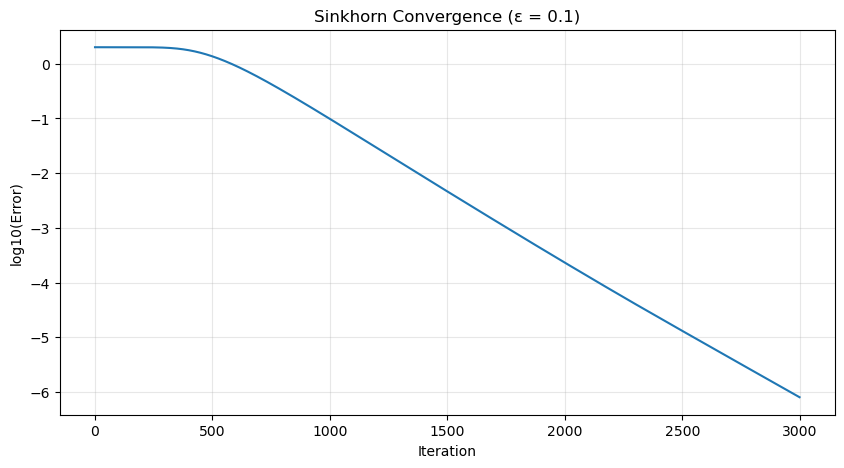

In [16]:
# Plot convergence
plt.figure(figsize=(10, 5))
plt.plot(np.log10(err_large))
plt.xlabel('Iteration')
plt.ylabel('log10(Error)')
plt.title(f'Sinkhorn Convergence (ε = {epsilon_large})')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Visualize flow (interactive)
threshold_large = F_sinkhorn_large_dense.max() / 50
fig = plot_mesh_with_flow_interactive(
    vertices,
    faces,
    F_sinkhorn_large_dense,
    z,
    threshold=threshold_large,
    title=f"Sinkhorn Flow (ε = {epsilon_large}, large regularization)",
    flow_color='orange',
    flow_width_scale=20.0,
    show_edges=True,
    edge_color='black',
    edge_width=0.45,
)
fig.show()

## 7. Flow Sinkhorn with Small Regularization

Now we use a smaller $\varepsilon$ to get closer to the exact solution.

In [19]:
# Small regularization
epsilon_small = 0.03
niter = 5000

print(f"Computing Sinkhorn flow with small regularization (ε = {epsilon_small})...")
start = time.time()
F_sinkhorn_small, err_small, h_small = sinkhorn_w1_sparse(Ws, z, epsilon=epsilon_small, niter=niter)
time_sinkhorn_small = time.time() - start

# Convert to dense
F_sinkhorn_small_dense = F_sinkhorn_small.todense()

# Compute cost
cost_small = np.sum(F_sinkhorn_small_dense * W)

print(f"Sinkhorn (small ε):")
print(f"  - Final error: {err_small[-1]:.2e}")
print(f"  - Cost: {cost_small:.6f}")
print(f"  - Relative cost error: {abs(cost_small - obj_exact) / obj_exact * 100:.2f}%")
print(f"  - Time: {time_sinkhorn_small:.2f}s")
print(f"  - Speedup vs exact: {time_exact / time_sinkhorn_small:.1f}x")

Computing Sinkhorn flow with small regularization (ε = 0.03)...
Sinkhorn (small ε):
  - Final error: 1.11e-09
  - Cost: 37.360394
  - Relative cost error: 78.08%
  - Time: 22.91s
  - Speedup vs exact: 0.8x


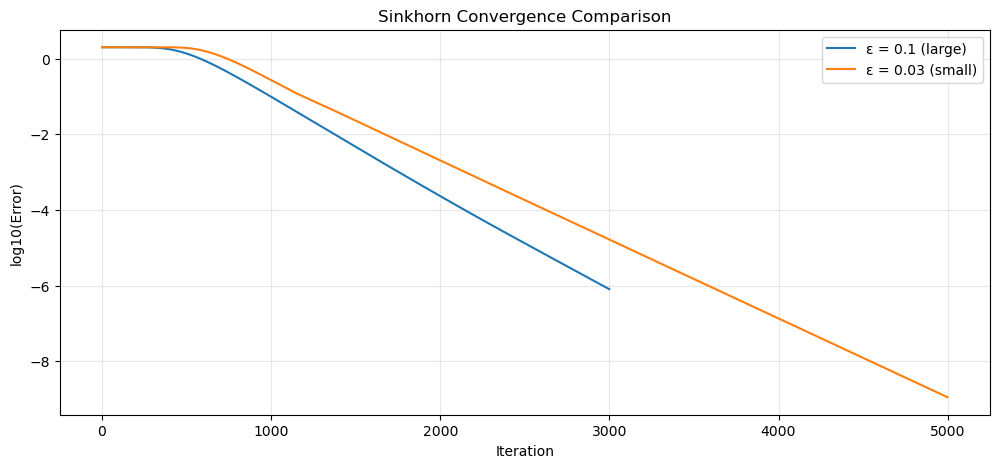

In [13]:
# Plot convergence comparison
plt.figure(figsize=(12, 5))
plt.plot(np.log10(err_large), label=f'ε = {epsilon_large} (large)')
plt.plot(np.log10(err_small), label=f'ε = {epsilon_small} (small)')
plt.xlabel('Iteration')
plt.ylabel('log10(Error)')
plt.title('Sinkhorn Convergence Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Visualize flow (interactive)
threshold_small = F_sinkhorn_small_dense.max() / 50
fig = plot_mesh_with_flow_interactive(
    vertices,
    faces,
    F_sinkhorn_small_dense,
    z,
    threshold=threshold_small,
    title=f"Sinkhorn Flow (ε = {epsilon_small}, small regularization)",
    flow_color='green',
    flow_width_scale=20.0,
    show_edges=True,
    edge_color='black',
    edge_width=0.45,
)
fig.show()